<a href="https://colab.research.google.com/github/maxsccavalcante/Topicos_Especiais_em_TI/blob/main/RealEstate_Regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/maxsccavalcante/FabricaSoftware/blob/main/RealEstatue_Regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão Linear - Preço de Imóveis em Taiwan

Como o que eu quero prever é um valor contínuo, o problema é de **regressão**, e o modelo que uso é a **Regressão Linear**.

**Roteiro que segui:**
1. Imports e configuração
2. Carga dos dados e padronização dos nomes das colunas
3. Análise exploratória
4. Separação entre features (X) e target (y)
5. Divisão treino/teste
6. Padronização das features
7. Treinamento do modelo
8. Predições
9. Avaliação
10. Validação cruzada
11. Visualizações e análise de resíduos
12. Modelo alternativo com transformação logarítmica
13. Conclusão

Base de dados: https://www.kaggle.com/datasets/quantbruce/real-estate-price-prediction

## 1. Imports e configuração

In [4]:
# Bibliotecas de manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
warnings.filterwarnings('ignore')

# Bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Semente fixa para a divisão treino/teste ser sempre a mesma e os resultados serem reproduzíveis
SEED = 42

print("Bibliotecas importadas com sucesso!")
print("Versão do Scikit-learn:", sklearn.__version__)

Bibliotecas importadas com sucesso!
Versão do Scikit-learn: 1.6.1


## 2. Carga dos dados e padronização dos nomes das colunas

Renomeio as colunas logo na entrada. Os nomes originais vêm com prefixos e espaços (`X3 distance to the nearest MRT station`), o que deixa o código pesado e os gráficos ilegíveis. Antes eu fazia esse `rename` no meio do notebook, o que criava confusão: metade das células usava os nomes antigos e a outra metade os novos — e havia até uma célula que chamava `df.columns` antes de o `df` existir, então o notebook quebrava se fosse rodado de cima para baixo.

**O que cada coluna representa:**

| Nome original | Nome que passei a usar | Significado |
|---|---|---|
| `No` | `Id` | Identificador sequencial do registro |
| `X1 transaction date` | `TransactionDate` | Data da transação em ano decimal (ex: 2013.250 ≈ março/2013) |
| `X2 house age` | `HouseAge` | Idade do imóvel em anos |
| `X3 distance to the nearest MRT station` | `DistanceMRT` | Distância até a estação de metrô mais próxima, em metros |
| `X4 number of convenience stores` | `ConvenienceStores` | Lojas de conveniência a pé no entorno |
| `X5 latitude` | `Latitude` | Latitude |
| `X6 longitude` | `Longitude` | Longitude |
| `Y house price of unit area` | `HousePricePerUnit` | **Target**: preço por unidade de área (10 mil NT$ por ping) |

In [5]:

try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Não estou no Colab - vou ler o arquivo local.")

df = pd.read_csv("Real Estate Regressão.csv")

# Renomeio tudo de uma vez, antes de qualquer análise
df = df.rename(columns = {
    'No': 'Id',
    'X1 transaction date': 'TransactionDate',
    'X2 house age': 'HouseAge',
    'X3 distance to the nearest MRT station': 'DistanceMRT',
    'X4 number of convenience stores': 'ConvenienceStores',
    'X5 latitude': 'Latitude',
    'X6 longitude': 'Longitude',
    'Y house price of unit area': 'HousePricePerUnit'
})

print("Dataset carregado!")
print(f"Formato: {df.shape[0]} imóveis e {df.shape[1]} colunas")
print("Colunas:", df.columns.tolist())
display(df.head())

Saving Real Estate Regressão.csv to Real Estate Regressão (2).csv
Dataset carregado!
Formato: 414 imóveis e 8 colunas
Colunas: ['Id', 'TransactionDate', 'HouseAge', 'DistanceMRT', 'ConvenienceStores', 'Latitude', 'Longitude', 'HousePricePerUnit']


,Id,TransactionDate,HouseAge,DistanceMRT,ConvenienceStores,Latitude,Longitude,HousePricePerUnit
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 3. Análise exploratória

In [6]:
# Estrutura geral: tipos de dado e valores preenchidos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 414 non-null    int64  
 1   TransactionDate    414 non-null    float64
 2   HouseAge           414 non-null    float64
 3   DistanceMRT        414 non-null    float64
 4   ConvenienceStores  414 non-null    int64  
 5   Latitude           414 non-null    float64
 6   Longitude          414 non-null    float64
 7   HousePricePerUnit  414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [7]:
# Resumo estatístico. Duas coisas me chamaram atenção aqui:
# 1) as escalas são muito diferentes entre si (a distância ao metrô vai a mais de 6.000
#    enquanto latitude e longitude variam na casa dos centésimos);
# 2) o preço máximo (117,5) está muito acima do terceiro quartil - é um outlier que aparece
#    depois na análise de resíduos.
df.describe().round(3)

,Id,TransactionDate,HouseAge,DistanceMRT,ConvenienceStores,Latitude,Longitude,HousePricePerUnit
count,414.000,414.000,414.000,414.000,414.000,414.000,414.000,414.000
mean,207.500,2013.149,17.713,1083.886,4.094,24.969,121.533,37.980
std,119.656,0.282,11.392,1262.110,2.946,0.012,0.015,13.606
min,1.000,2012.667,0.000,23.383,0.000,24.932,121.474,7.600
25%,104.250,2012.917,9.025,289.325,1.000,24.963,121.528,27.700
50%,207.500,2013.167,16.100,492.231,4.000,24.971,121.539,38.450
75%,310.750,2013.417,28.150,1454.279,6.000,24.977,121.543,46.600
max,414.000,2013.583,43.800,6488.021,10.000,25.015,121.566,117.500


In [8]:
# Confirmo que não há valores ausentes - esta base está completa, então não preciso imputar nada
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print(f"\nTotal de valores ausentes: {df.isnull().sum().sum()}")

Valores ausentes por coluna:
Id                   0
TransactionDate      0
HouseAge             0
DistanceMRT          0
ConvenienceStores    0
Latitude             0
Longitude            0
HousePricePerUnit    0
dtype: int64

Total de valores ausentes: 0


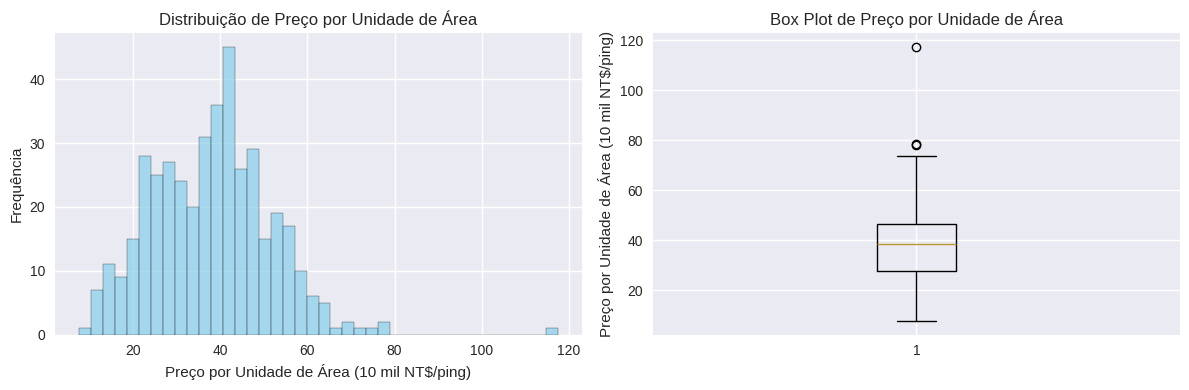

=== ESTATÍSTICAS DO TARGET ===
Mínimo:        7.60 10 mil NT$/ping
Máximo:        117.50 10 mil NT$/ping
Média:         37.98 10 mil NT$/ping
Mediana:       38.45 10 mil NT$/ping
Desvio padrão: 13.61 10 mil NT$/ping


In [9]:
# Distribuição do target. Defino aqui o nome e a unidade que uso nos gráficos e nos prints
# do notebook inteiro. Na versão anterior eu tinha colocado o nome da coluna no lugar do nome
# amigável e "Preço do imóvel" no lugar da unidade, o que deixava os rótulos sem sentido
# (saía coisa como "Erro médio: 5.31 Preço do imóvel").
nome_target = "Preço por Unidade de Área"
unidade_target = "10 mil NT$/ping"

y_plot = df['HousePricePerUnit']

plt.figure(figsize = (12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_plot, bins = 40, alpha = 0.7, color = 'skyblue', edgecolor = 'black')
plt.title(f'Distribuição de {nome_target}')
plt.xlabel(f'{nome_target} ({unidade_target})')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
plt.boxplot(y_plot, vert = True)
plt.title(f'Box Plot de {nome_target}')
plt.ylabel(f'{nome_target} ({unidade_target})')

plt.tight_layout()
plt.show()

print("=== ESTATÍSTICAS DO TARGET ===")
print(f"Mínimo:        {y_plot.min():.2f} {unidade_target}")
print(f"Máximo:        {y_plot.max():.2f} {unidade_target}")
print(f"Média:         {y_plot.mean():.2f} {unidade_target}")
print(f"Mediana:       {y_plot.median():.2f} {unidade_target}")
print(f"Desvio padrão: {y_plot.std():.2f} {unidade_target}")

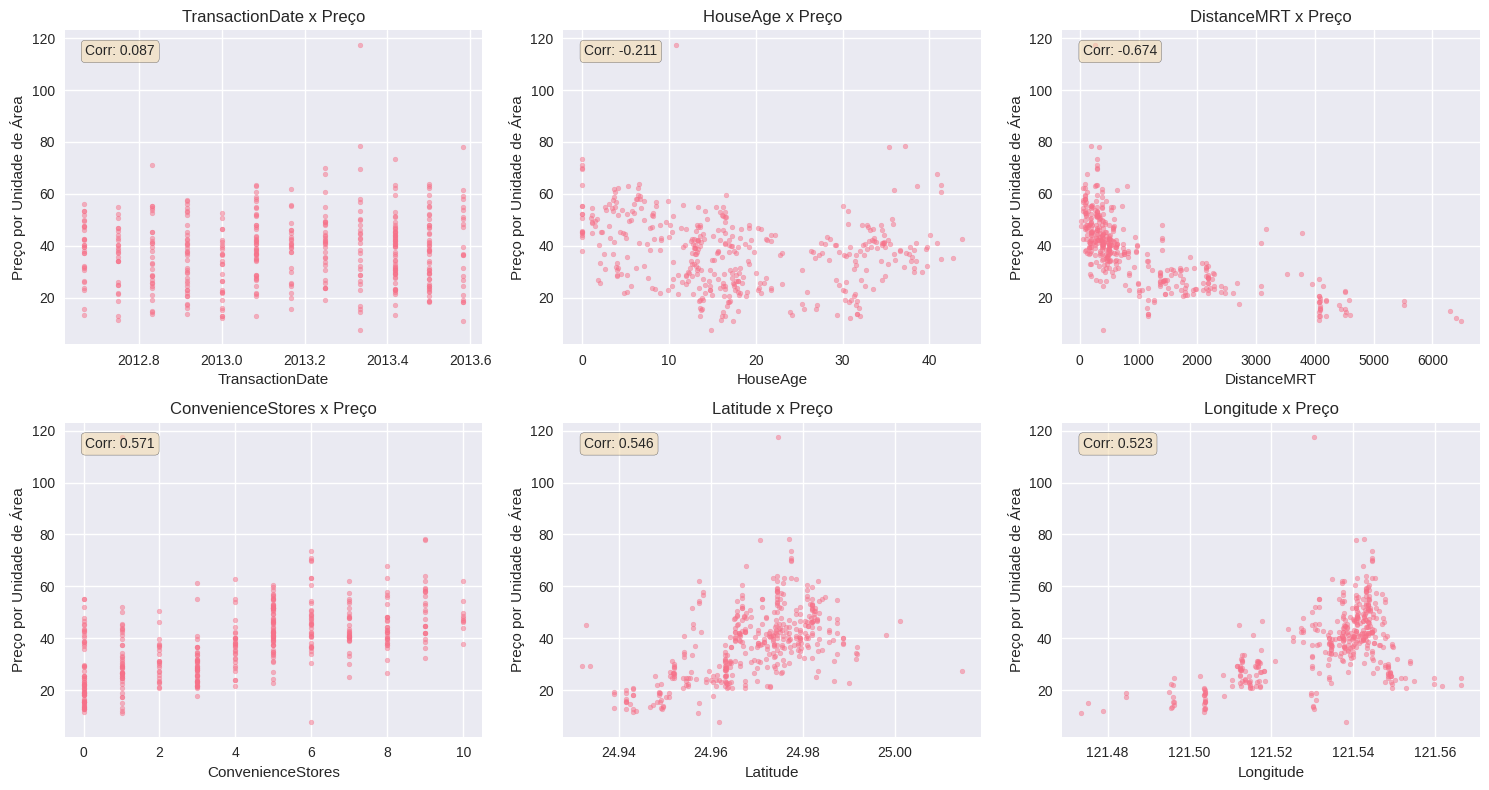

In [10]:
# Relação de cada feature com o target, com a correlação anotada em cada gráfico.
# Já excluo o Id daqui, porque ele é só um número de linha e não faz sentido correlacionar.
features_exploracao = [c for c in df.columns if c not in ['Id', 'HousePricePerUnit']]

n_cols = 3
n_rows = -(-len(features_exploracao) // n_cols)

plt.figure(figsize = (15, 4 * n_rows))

for i, coluna in enumerate(features_exploracao):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.scatter(df[coluna], df['HousePricePerUnit'], alpha = 0.5, s = 12)
    plt.xlabel(coluna)
    plt.ylabel(nome_target)
    plt.title(f'{coluna} x Preço')

    correlacao = df[coluna].corr(df['HousePricePerUnit'])
    plt.text(0.05, 0.92, f'Corr: {correlacao:.3f}',
             transform = plt.gca().transAxes,
             bbox = dict(boxstyle = "round", facecolor = 'wheat', alpha = 0.6))

plt.tight_layout()
plt.show()

Olhando os gráficos acima, o ponto mais importante é a relação entre `DistanceMRT` e o preço: ela não é uma reta, é uma curva que cai muito rápido nos primeiros metros e depois quase estabiliza. Isso significa que a Regressão Linear, que só consegue ajustar retas, não captura bem esse comportamento. É justamente por causa disso que, na Etapa 12, eu testo um modelo alternativo aplicando logaritmo nessa variável.

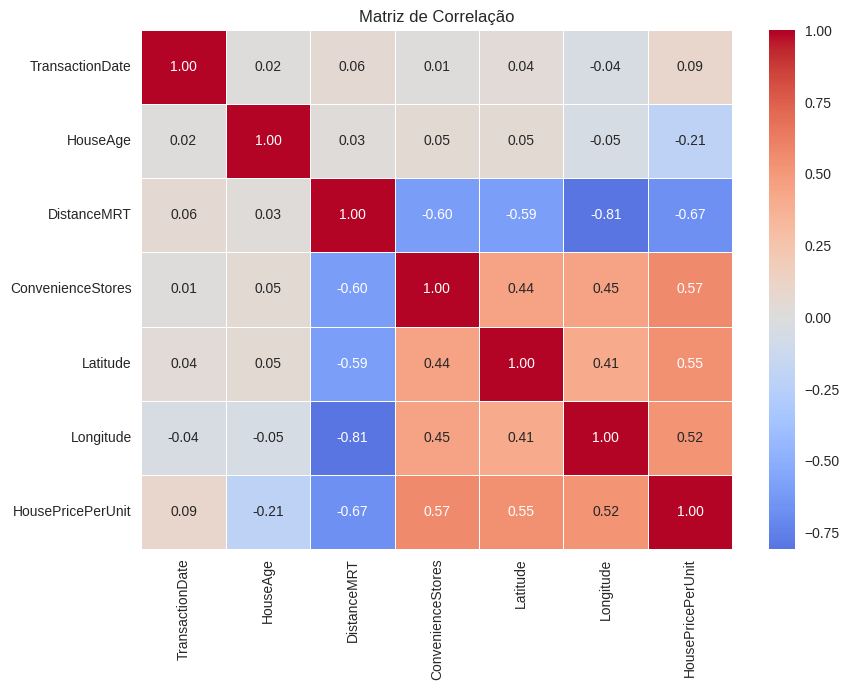

Correlação de cada feature com o preço, da mais forte para a mais fraca:
DistanceMRT         -0.674
ConvenienceStores    0.571
Latitude             0.546
Longitude            0.523
HouseAge            -0.211
TransactionDate      0.087
Name: HousePricePerUnit, dtype: float64


In [11]:
# Matriz de correlação entre todas as variáveis (sem o Id)
matriz_corr = df.drop(columns = ['Id']).corr()

plt.figure(figsize = (9, 7))
sns.heatmap(matriz_corr, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5, center = 0)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

print("Correlação de cada feature com o preço, da mais forte para a mais fraca:")
print(matriz_corr['HousePricePerUnit'].drop('HousePricePerUnit').sort_values(key = abs, ascending = False).round(3))

## 4. Separação entre features (X) e target (y)

- **X (features)**: as variáveis de entrada.
- **y (target)**: `HousePricePerUnit`, o valor que quero prever.

Removo a coluna `Id` junto com o target. Ela é apenas a numeração das linhas do arquivo: não tem significado nenhum sobre o imóvel, mas o modelo trataria aquilo como um número qualquer e tentaria extrair padrão dali. Na versão anterior eu cheguei a plotar e analisar o `Id` como se fosse uma feature antes de removê-lo, o que só poluía a análise.

In [12]:
X = df.drop(columns = ['HousePricePerUnit', 'Id'])
y = df['HousePricePerUnit']

print(f"X: {X.shape[0]} amostras e {X.shape[1]} features")
print(f"Features: {X.columns.tolist()}")
print(f"y: {y.shape[0]} valores | faixa de {y.min():.2f} a {y.max():.2f}")

X: 414 amostras e 6 features
Features: ['TransactionDate', 'HouseAge', 'DistanceMRT', 'ConvenienceStores', 'Latitude', 'Longitude']
y: 414 valores | faixa de 7.60 a 117.50


## 5. Divisão treino/teste

Separo 80% dos imóveis para treino e 20% para teste. O modelo só aprende com o treino; o teste fica reservado para medir o desempenho em dados que ele nunca viu, que é o que simula o uso real.

Uso `random_state = SEED` para que a divisão seja sempre a mesma e os números não mudem a cada execução.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = SEED
)

print("=== DIVISÃO DOS DADOS ===")
print(f"Treino: {X_train.shape[0]} imóveis ({X_train.shape[0] / len(X) * 100:.1f}%)")
print(f"Teste:  {X_test.shape[0]} imóveis ({X_test.shape[0] / len(X) * 100:.1f}%)")

print("\n=== DISTRIBUIÇÃO DO TARGET ===")
print(f"Treino -> média: {y_train.mean():.2f} | desvio: {y_train.std():.2f} {unidade_target}")
print(f"Teste  -> média: {y_test.mean():.2f} | desvio: {y_test.std():.2f} {unidade_target}")
print("\nAs distribuições ficaram parecidas, então a divisão foi equilibrada.")

=== DIVISÃO DOS DADOS ===
Treino: 331 imóveis (80.0%)
Teste:  83 imóveis (20.0%)

=== DISTRIBUIÇÃO DO TARGET ===
Treino -> média: 38.39 | desvio: 13.74 10 mil NT$/ping
Teste  -> média: 36.34 | desvio: 13.03 10 mil NT$/ping

As distribuições ficaram parecidas, então a divisão foi equilibrada.


## 6. Padronização das features

O `StandardScaler` coloca todas as features com média 0 e desvio 1.

Como sempre, o `scaler` é ajustado só no treino e depois aplicado ao teste, para não vazar informação.

In [14]:
print("=== ANTES DA PADRONIZAÇÃO ===")
display(X_train.describe().round(3))

# O scaler aprende média e desvio APENAS no treino
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns = X_train.columns, index = X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns, index = X_test.index)

print("\n=== DEPOIS DA PADRONIZAÇÃO ===")
display(X_train_scaled.describe().round(3))
print("Todas as features do treino agora têm média ≈ 0 e desvio ≈ 1.")

=== ANTES DA PADRONIZAÇÃO ===


,TransactionDate,HouseAge,DistanceMRT,ConvenienceStores,Latitude,Longitude
count,331.000,331.000,331.000,331.000,331.000,331.000
mean,2013.167,17.289,1059.604,4.145,24.969,121.534
std,0.282,11.327,1217.930,2.954,0.012,0.015
min,2012.667,0.000,23.383,0.000,24.932,121.475
25%,2012.917,8.450,289.325,1.000,24.963,121.530
50%,2013.167,15.900,492.231,4.000,24.971,121.539
75%,2013.417,27.200,1442.932,6.000,24.978,121.543
max,2013.583,43.800,6306.153,10.000,25.015,121.566



=== DEPOIS DA PADRONIZAÇÃO ===


,TransactionDate,HouseAge,DistanceMRT,ConvenienceStores,Latitude,Longitude
count,331.000,331.000,331.000,331.000,331.000,331.000
mean,-0.000,0.000,-0.000,0.000,0.000,0.000
std,1.002,1.002,1.002,1.002,1.002,1.002
min,-1.777,-1.529,-0.852,-1.405,-2.989,-3.927
25%,-0.888,-0.781,-0.633,-1.066,-0.507,-0.282
50%,0.001,-0.123,-0.467,-0.049,0.142,0.353
75%,0.890,0.876,0.315,0.629,0.716,0.642
max,1.481,2.344,4.314,1.985,3.631,2.166


Todas as features do treino agora têm média ≈ 0 e desvio ≈ 1.


## 7. Treinamento do modelo

A Regressão Linear procura os coeficientes que minimizam a soma dos erros ao quadrado, ajustando a equação:

`preço = β₀ + β₁·x₁ + β₂·x₂ + ... + βₙ·xₙ`

In [15]:
modelo = LinearRegression()

print("=== TREINAMENTO ===")
print(f"Treinando com {X_train_scaled.shape[0]} amostras e {X_train_scaled.shape[1]} features")

modelo.fit(X_train_scaled, y_train)

print("Treinamento concluído!")
print(f"\nIntercepto (β₀): {modelo.intercept_:.4f}")

coeficientes = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coeficiente': modelo.coef_
}).sort_values('coeficiente', key = abs, ascending = False).reset_index(drop = True)

print("\n=== COEFICIENTES (ordenados por influência) ===")
display(coeficientes.round(4))

print("Equação do modelo:")
equacao = f"Preço = {modelo.intercept_:.4f}"
for feature, coef in zip(X_train_scaled.columns, modelo.coef_):
    sinal = "+" if coef >= 0 else "-"
    equacao += f" {sinal} {abs(coef):.4f}*{feature}"
print(equacao)

=== TREINAMENTO ===
Treinando com 331 amostras e 6 features
Treinamento concluído!

Intercepto (β₀): 38.3915

=== COEFICIENTES (ordenados por influência) ===


,feature,coeficiente
0,DistanceMRT,-5.7869
1,ConvenienceStores,3.2189
2,HouseAge,-3.0627
3,Latitude,2.8551
4,TransactionDate,1.5296
5,Longitude,-0.4410


Equação do modelo:
Preço = 38.3915 + 1.5296*TransactionDate - 3.0627*HouseAge - 5.7869*DistanceMRT + 3.2189*ConvenienceStores + 2.8551*Latitude - 0.4410*Longitude


## 8. Predições

In [16]:
y_train_pred = modelo.predict(X_train_scaled)
y_test_pred = modelo.predict(X_test_scaled)

print("=== AMOSTRA DAS PREDIÇÕES (conjunto de teste) ===")
comparacao = pd.DataFrame({
    'real': y_test,
    'predito': y_test_pred.round(2),
    'erro': (y_test - y_test_pred).round(2),
    'erro_percentual': ((y_test - y_test_pred).abs() / y_test * 100).round(1)
})
display(comparacao.head(10))

print(f"Média real no teste:    {y_test.mean():.2f} {unidade_target}")
print(f"Média predita no teste: {y_test_pred.mean():.2f} {unidade_target}")

=== AMOSTRA DAS PREDIÇÕES (conjunto de teste) ===


,real,predito,erro,erro_percentual
358,45.1,47.89,-2.79,6.2
350,42.3,41.16,1.14,2.7
373,52.2,44.27,7.93,15.2
399,37.3,40.20,-2.90,7.8
369,22.8,27.51,-4.71,20.7
72,36.3,45.11,-8.81,24.3
262,53.0,44.63,8.37,15.8
140,51.4,46.36,5.04,9.8
93,16.1,23.62,-7.52,46.7
70,59.0,54.33,4.67,7.9


Média real no teste:    36.34 10 mil NT$/ping
Média predita no teste: 36.22 10 mil NT$/ping


## 9. Avaliação do modelo

As métricas que uso:

- **R²**: percentual da variação do preço que o modelo consegue explicar. Vai de 0 a 1 (pode ser negativo se o modelo for pior que prever a média).
- **MAE (Erro Absoluto Médio)**: o erro médio em módulo, na mesma unidade do preço. É a métrica mais fácil de interpretar.
- **MSE (Erro Quadrático Médio)**: média dos erros ao quadrado, penaliza mais os erros grandes.
- **RMSE**: raiz do MSE, volta para a unidade original do preço.


In [17]:
def avaliar(y_true, y_pred, nome_conjunto):
    """Calcula e exibe as métricas de regressão de um conjunto"""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"=== CONJUNTO DE {nome_conjunto.upper()} ===")
    print(f"R²:   {r2:.4f} ({r2 * 100:.2f}% da variância explicada)")
    print(f"MAE:  {mae:.4f} {unidade_target}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f} {unidade_target}")

    return r2, mse, rmse, mae

train_r2, train_mse, train_rmse, train_mae = avaliar(y_train, y_train_pred, "treino")
print()
test_r2, test_mse, test_rmse, test_mae = avaliar(y_test, y_test_pred, "teste")

=== CONJUNTO DE TREINO ===
R²:   0.5581 (55.81% da variância explicada)
MAE:  6.3397 10 mil NT$/ping
MSE:  83.1135
RMSE: 9.1167 10 mil NT$/ping

=== CONJUNTO DE TESTE ===
R²:   0.6811 (68.11% da variância explicada)
MAE:  5.3054 10 mil NT$/ping
MSE:  53.5056
RMSE: 7.3148 10 mil NT$/ping


In [18]:
# Tabela comparativa entre treino e teste
resumo = pd.DataFrame({
    'métrica': ['R²', 'MAE', 'MSE', 'RMSE'],
    'treino': [train_r2, train_mae, train_mse, train_rmse],
    'teste': [test_r2, test_mae, test_mse, test_rmse]
}).round(4)

display(resumo)

diferenca_r2 = train_r2 - test_r2
print(f"Diferença de R² (treino - teste): {diferenca_r2:.4f}")

if diferenca_r2 > 0.10:
    print("Diferença alta: possível overfitting, o modelo foi bem no treino e mal no teste.")
elif diferenca_r2 < -0.05:
    print("O R² do teste ficou ACIMA do treino. Isso não é erro: com apenas 83 imóveis no teste,")
    print("o resultado depende muito de quais imóveis caíram nesse sorteio. Se os casos mais")
    print("difíceis ficaram no treino, o teste sai melhor por acaso. É por isso que na próxima")
    print("etapa eu faço validação cruzada, que não depende de um único sorteio.")
else:
    print("Diferença pequena entre treino e teste: o modelo está generalizando bem.")

,métrica,treino,teste
0,R²,0.5581,0.6811
1,MAE,6.3397,5.3054
2,MSE,83.1135,53.5056
3,RMSE,9.1167,7.3148


Diferença de R² (treino - teste): -0.1229
O R² do teste ficou ACIMA do treino. Isso não é erro: com apenas 83 imóveis no teste,
o resultado depende muito de quais imóveis caíram nesse sorteio. Se os casos mais
difíceis ficaram no treino, o teste sai melhor por acaso. É por isso que na próxima
etapa eu faço validação cruzada, que não depende de um único sorteio.


## 10. Validação cruzada

Na validação cruzada a base é dividida em 5 partes: o modelo é treinado 5 vezes, e a cada rodada uma parte diferente fica de fora para servir de teste. A média dos 5 resultados é uma estimativa bem mais estável do desempenho real.

Coloquei o `StandardScaler` dentro de um `Pipeline` para que ele seja reajustado dentro de cada divisão, usando só os dados de treino daquela rodada. Se eu padronizasse a base inteira antes, haveria vazamento de informação entre as partes.

In [19]:
pipeline = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo', LinearRegression())
])

cv = KFold(n_splits = 5, shuffle = True, random_state = SEED)

scores_r2 = cross_val_score(pipeline, X, y, cv = cv, scoring = 'r2')
scores_rmse = -cross_val_score(pipeline, X, y, cv = cv, scoring = 'neg_root_mean_squared_error')

print("=== VALIDAÇÃO CRUZADA (5 divisões) ===")
print("R² por divisão:", scores_r2.round(4))
print(f"R² médio: {scores_r2.mean():.4f} (+/- {scores_r2.std():.4f})")
print()
print("RMSE por divisão:", scores_rmse.round(4))
print(f"RMSE médio: {scores_rmse.mean():.4f} {unidade_target}")
print()
print(f"Comparando: R² da divisão única foi {test_r2:.4f} e o R² médio da validação cruzada")
print("é a estimativa em que eu confio mais para descrever o desempenho do modelo.")

=== VALIDAÇÃO CRUZADA (5 divisões) ===
R² por divisão: [0.6811 0.4366 0.6331 0.6059 0.4899]
R² médio: 0.5693 (+/- 0.0914)

RMSE por divisão: [ 7.3148  8.6029  8.2244  8.5824 11.2559]
RMSE médio: 8.7961 10 mil NT$/ping

Comparando: R² da divisão única foi 0.6811 e o R² médio da validação cruzada
é a estimativa em que eu confio mais para descrever o desempenho do modelo.


## 11. Visualizações e análise de resíduos


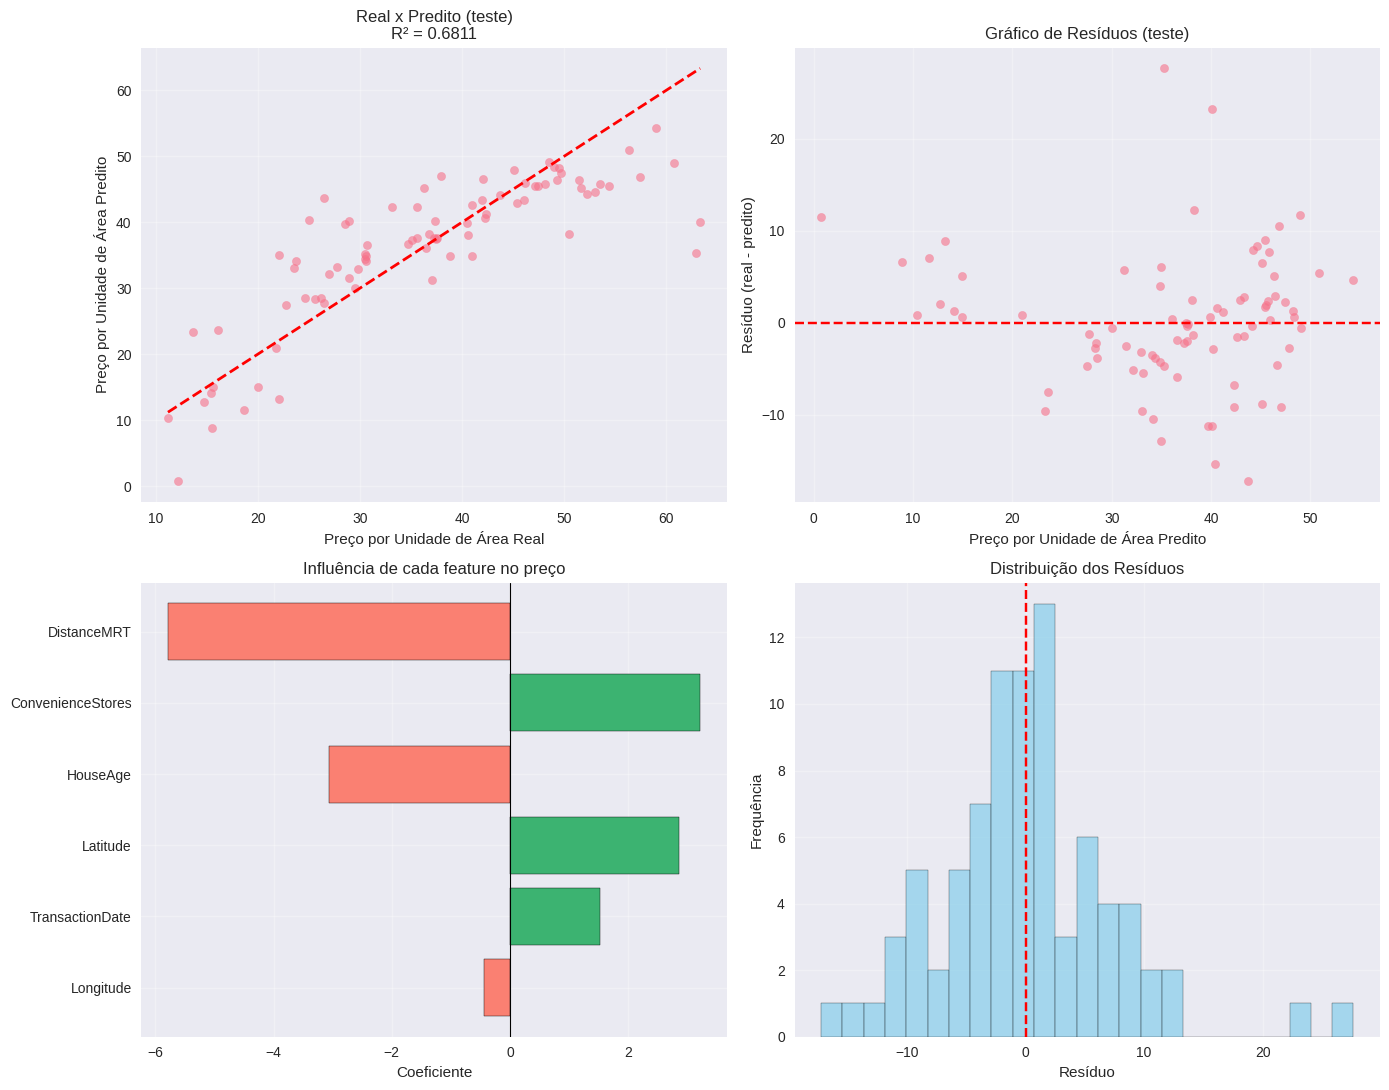

In [20]:
fig, axes = plt.subplots(2, 2, figsize = (14, 11))
residuos = y_test - y_test_pred

# 1. Real x Predito - quanto mais perto da linha tracejada, melhor a predição
axes[0, 0].scatter(y_test, y_test_pred, alpha = 0.6, s = 35)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth = 2)
axes[0, 0].set_xlabel(f'{nome_target} Real')
axes[0, 0].set_ylabel(f'{nome_target} Predito')
axes[0, 0].set_title(f'Real x Predito (teste)\nR² = {test_r2:.4f}')
axes[0, 0].grid(True, alpha = 0.3)

# 2. Resíduos - o ideal é uma nuvem sem padrão em torno do zero
axes[0, 1].scatter(y_test_pred, residuos, alpha = 0.6, s = 35)
axes[0, 1].axhline(y = 0, color = 'red', linestyle = '--')
axes[0, 1].set_xlabel(f'{nome_target} Predito')
axes[0, 1].set_ylabel('Resíduo (real - predito)')
axes[0, 1].set_title('Gráfico de Resíduos (teste)')
axes[0, 1].grid(True, alpha = 0.3)

# 3. Coeficientes - qual feature pesa mais na predição
cores = ['mediumseagreen' if c > 0 else 'salmon' for c in coeficientes['coeficiente']]
axes[1, 0].barh(coeficientes['feature'], coeficientes['coeficiente'], color = cores, edgecolor = 'black')
axes[1, 0].axvline(x = 0, color = 'black', linewidth = 0.8)
axes[1, 0].set_xlabel('Coeficiente')
axes[1, 0].set_title('Influência de cada feature no preço')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha = 0.3)

# 4. Distribuição dos resíduos - deveria parecer um sino centrado no zero
axes[1, 1].hist(residuos, bins = 25, alpha = 0.7, color = 'skyblue', edgecolor = 'black')
axes[1, 1].axvline(x = 0, color = 'red', linestyle = '--')
axes[1, 1].set_xlabel('Resíduo')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição dos Resíduos')
axes[1, 1].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

In [21]:
# Leitura dos gráficos acima
print("=== COMO EU LEIO ESSES GRÁFICOS ===")
print("1. Real x Predito: os pontos acompanham a linha tracejada na faixa de preços comuns,")
print("   mas o modelo subestima os imóveis mais caros - eles ficam bem abaixo da diagonal.")
print("2. Resíduos: a nuvem não é totalmente aleatória; sobram erros grandes nas pontas,")
print("   o que indica que existe relação não linear que a reta não consegue capturar.")
print("3. Coeficientes: a distância até o metrô é a variável de maior peso, e com sinal negativo.")
print("4. Distribuição dos resíduos: aproximadamente centrada no zero, mas com cauda à direita")
print("   por causa dos imóveis de preço muito alto.")
print()
print(f"Média dos resíduos: {residuos.mean():.4f} (esperado: próximo de zero)")
print(f"Maior erro para cima:  {residuos.max():.2f} {unidade_target}")
print(f"Maior erro para baixo: {residuos.min():.2f} {unidade_target}")

=== COMO EU LEIO ESSES GRÁFICOS ===
1. Real x Predito: os pontos acompanham a linha tracejada na faixa de preços comuns,
   mas o modelo subestima os imóveis mais caros - eles ficam bem abaixo da diagonal.
2. Resíduos: a nuvem não é totalmente aleatória; sobram erros grandes nas pontas,
   o que indica que existe relação não linear que a reta não consegue capturar.
3. Coeficientes: a distância até o metrô é a variável de maior peso, e com sinal negativo.
4. Distribuição dos resíduos: aproximadamente centrada no zero, mas com cauda à direita
   por causa dos imóveis de preço muito alto.

Média dos resíduos: 0.1234 (esperado: próximo de zero)
Maior erro para cima:  27.63 10 mil NT$/ping
Maior erro para baixo: -17.22 10 mil NT$/ping


In [22]:
# Análise das features mais influentes e um exemplo de predição individual
print("=== AS 3 FEATURES MAIS INFLUENTES ===")
for _, linha in coeficientes.head(3).iterrows():
    direcao = "AUMENTA" if linha['coeficiente'] > 0 else "DIMINUI"
    print(f"• {linha['feature']}: {direcao} o preço (coeficiente = {linha['coeficiente']:.4f})")

print(f"\n=== RESUMO DO DESEMPENHO ===")
print(f"• O modelo explica {test_r2 * 100:.1f}% da variação do preço no conjunto de teste")
print(f"• Erro médio de {test_mae:.2f} {unidade_target}, o que representa cerca de "
      f"{test_mae / y_test.mean() * 100:.1f}% do preço médio")

print(f"\n=== EXEMPLO DE PREDIÇÃO ===")
idx = 0
imovel = X_test_scaled.iloc[idx:idx + 1]
real = y_test.iloc[idx]
predito = modelo.predict(imovel)[0]

print("Características do imóvel (valores originais):")
display(X_test.iloc[idx:idx + 1])
print(f"Preço real:    {real:.2f} {unidade_target}")
print(f"Preço predito: {predito:.2f} {unidade_target}")
print(f"Erro:          {abs(real - predito):.2f} {unidade_target}")

=== AS 3 FEATURES MAIS INFLUENTES ===
• DistanceMRT: DIMINUI o preço (coeficiente = -5.7869)
• ConvenienceStores: AUMENTA o preço (coeficiente = 3.2189)
• HouseAge: DIMINUI o preço (coeficiente = -3.0627)

=== RESUMO DO DESEMPENHO ===
• O modelo explica 68.1% da variação do preço no conjunto de teste
• Erro médio de 5.31 10 mil NT$/ping, o que representa cerca de 14.6% do preço médio

=== EXEMPLO DE PREDIÇÃO ===
Características do imóvel (valores originais):


,TransactionDate,HouseAge,DistanceMRT,ConvenienceStores,Latitude,Longitude
358,2013.167,1.1,193.5845,6,24.96571,121.54089


Preço real:    45.10 10 mil NT$/ping
Preço predito: 47.89 10 mil NT$/ping
Erro:          2.79 10 mil NT$/ping


## 12. Modelo alternativo: logaritmo da distância ao metrô

Na análise exploratória eu observei que a relação entre a distância até o metrô e o preço é uma curva, não uma reta: sair de 100 m para 600 m derruba muito o preço, mas sair de 5.000 m para 5.500 m quase não muda nada. A Regressão Linear não consegue representar isso.

Uma forma simples de contornar sem trocar de algoritmo é aplicar o logaritmo nessa variável. Com isso a relação entre `log(DistanceMRT)` e o preço fica bem mais próxima de uma reta, que é o que o modelo sabe ajustar. Testo abaixo e comparo com o modelo base, usando a mesma divisão e a mesma validação cruzada para a comparação ser justa.

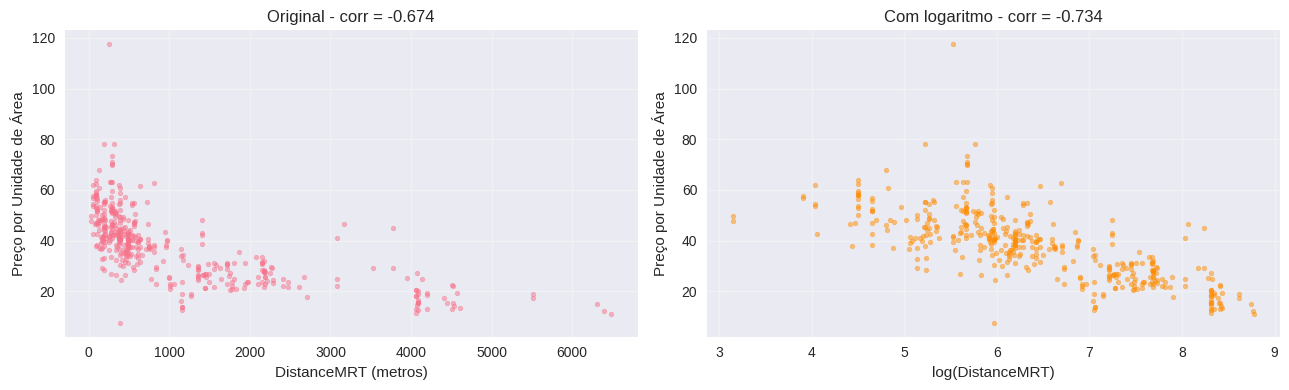

In [23]:
# Comparação visual: distância original x distância em escala logarítmica
fig, axes = plt.subplots(1, 2, figsize = (13, 4))

axes[0].scatter(df['DistanceMRT'], df['HousePricePerUnit'], alpha = 0.5, s = 12)
axes[0].set_xlabel('DistanceMRT (metros)')
axes[0].set_ylabel(nome_target)
axes[0].set_title(f"Original - corr = {df['DistanceMRT'].corr(df['HousePricePerUnit']):.3f}")
axes[0].grid(True, alpha = 0.3)

log_dist = np.log(df['DistanceMRT'])
axes[1].scatter(log_dist, df['HousePricePerUnit'], alpha = 0.5, s = 12, color = 'darkorange')
axes[1].set_xlabel('log(DistanceMRT)')
axes[1].set_ylabel(nome_target)
axes[1].set_title(f"Com logaritmo - corr = {log_dist.corr(df['HousePricePerUnit']):.3f}")
axes[1].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

In [24]:
# Monto o X alternativo trocando a distância pelo seu logaritmo
X_log = X.copy()
X_log['DistanceMRT'] = np.log(X_log['DistanceMRT'])

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y,
    test_size = 0.2,
    random_state = SEED
)

scaler_log = StandardScaler()
scaler_log.fit(X_train_log)

X_train_log_scaled = scaler_log.transform(X_train_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

modelo_log = LinearRegression()
modelo_log.fit(X_train_log_scaled, y_train_log)

y_test_pred_log = modelo_log.predict(X_test_log_scaled)

test_r2_log = r2_score(y_test_log, y_test_pred_log)
test_rmse_log = np.sqrt(mean_squared_error(y_test_log, y_test_pred_log))
test_mae_log = mean_absolute_error(y_test_log, y_test_pred_log)

# Validação cruzada do modelo alternativo, para não depender de um único sorteio
scores_r2_log = cross_val_score(pipeline, X_log, y, cv = cv, scoring = 'r2')

comparativo = pd.DataFrame({
    'modelo': ['Base (distância original)', 'Alternativo (log da distância)'],
    'R2_teste': [test_r2, test_r2_log],
    'RMSE_teste': [test_rmse, test_rmse_log],
    'MAE_teste': [test_mae, test_mae_log],
    'R2_medio_validacao_cruzada': [scores_r2.mean(), scores_r2_log.mean()]
}).round(4)

display(comparativo)

if scores_r2_log.mean() > scores_r2.mean():
    ganho = (scores_r2_log.mean() - scores_r2.mean()) * 100
    print(f"O modelo com o logaritmo da distância ficou melhor: ganho de {ganho:.2f} pontos")
    print("percentuais no R² médio da validação cruzada. Ou seja, valeu a pena tratar a")
    print("não linearidade em vez de simplesmente aceitar o ajuste da reta.")
else:
    print("Neste caso a transformação não trouxe ganho - fico com o modelo base.")

,modelo,R2_teste,RMSE_teste,MAE_teste,R2_medio_validacao_cruzada
0,Base (distância original),0.6811,7.3148,5.3054,0.5693
1,Alternativo (log da distância),0.7257,6.7837,4.3934,0.6376


O modelo com o logaritmo da distância ficou melhor: ganho de 6.83 pontos
percentuais no R² médio da validação cruzada. Ou seja, valeu a pena tratar a
não linearidade em vez de simplesmente aceitar o ajuste da reta.


## 13. Conclusão

**O que eu fiz:** carreguei a base de imóveis de Sindian, padronizei os nomes das colunas, explorei a distribuição do preço e a relação de cada variável com ele, separei treino e teste, padronizei as features, treinei uma Regressão Linear, avaliei com R², MAE, MSE e RMSE, confirmei o resultado com validação cruzada e ainda testei um modelo alternativo tratando a não linearidade da distância ao metrô.

**Resultados do modelo base:** R² de 0,681 no teste e 0,558 no treino, com RMSE de 7,31 e MAE de 5,31 — o erro médio equivale a cerca de 15% do preço médio dos imóveis. O R² do teste ter ficado acima do treino chamou minha atenção, mas isso se explica pelo tamanho pequeno do conjunto de teste (83 imóveis): o resultado depende muito de quais imóveis caíram no sorteio. Por isso passei a olhar o R² médio da validação cruzada como a estimativa mais confiável.

**O que as variáveis dizem:** a distância até a estação de metrô é de longe o fator mais determinante, e com sinal negativo — quanto mais longe do metrô, mais barato o imóvel. Depois vêm a quantidade de lojas de conveniência no entorno (positiva, indica um bairro com mais estrutura) e a idade do imóvel (negativa, imóvel mais velho vale menos). A data da transação tem efeito pequeno e positivo, coerente com a valorização do período coberto pela base, e a longitude é praticamente irrelevante. Ou seja: o modelo está basicamente dizendo que localização e proximidade do transporte público é o que define preço em Sindian.

**Sobre o modelo alternativo:** trocar a distância pelo seu logaritmo aproximou a relação de uma reta e melhorou o ajuste em relação ao modelo base — o ganho exato sai no comparativo impresso na Etapa 12. Isso mostra que boa parte da limitação do modelo original não era falta de dados, e sim o fato de eu estar tentando ajustar uma reta a uma relação curva.

